# Probabilistic Risk Analysis

This notebook reproduces figures and tables for probabilistic/synthetic hurricane analysis.

**Paper Figures:**
- **Fig. 3**: Baseline systemic risk (ERA5 10,000-year)
- **Fig. 4**: Climate systemic risk scenarios
- **Fig. 5**: Policy divergence
- **Fig. 6**: Building code sensitivity

**Supplementary Information:**
- **SI Fig. 1**: Loss return period curves

**Data Requirements:**
- `results/mc_runs/emanuel_era5_baseline_*/iterations.csv` (ERA5 baseline MC results)
- `results/mc_runs/emanuel_{gcm}_ssp245cal_baseline_*/iterations.csv` (Climate scenario results)
- `results/mc_runs/emanuel_era5_{policy}_*/iterations.csv` (Policy scenario results)
- `results/mc_runs/emanuel_{gcm}_ssp245cal_buildingcode_w{w}f{f}_*/iterations.csv` (Building code sensitivity)

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from scipy import stats

# Paths
RESULTS_DIR = Path('../results')
MC_DIR = RESULTS_DIR / 'mc_runs'
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR = RESULTS_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Helper: Load Emanuel MC results
def load_mc_results(run_dir):
    """Load Monte Carlo results from a run directory (iterations.csv)."""
    csv_path = run_dir / 'iterations.csv'
    if csv_path.exists():
        return pd.read_csv(csv_path)
    return None

def get_latest_run(prefix):
    """Get the most recent run directory matching prefix."""
    runs = sorted(MC_DIR.glob(f'{prefix}*'), key=lambda p: p.stat().st_mtime, reverse=True)
    return runs[0] if runs else None

In [3]:
# Load baseline ERA5 results
baseline_dir = get_latest_run('emanuel_era5_baseline')
if baseline_dir:
    baseline_results = load_mc_results(baseline_dir)
else:
    print("No baseline results found - run the Emanuel TC workflow first")
    baseline_results = None

---
## Fig. 3: Baseline Systemic Risk (ERA5)

10,000-year Monte Carlo analysis showing insurer defaults and institutional stress distribution.

In [4]:
FHCF_CAP = 17e9  # $17B statewide cap

# Calculate annual exceedance probabilities for key thresholds

# Bootstrap function to compute uncertainty bounds
def compute_uncertainty_bounds(condition_array, n_bootstrap=1000, percentiles=[10, 90]):
    """
    Compute percentile-based uncertainty bounds for binary outcomes using bootstrap.
    
    Parameters:
    -----------
    condition_array : array-like of bool
        Boolean array indicating whether condition is met for each year
    n_bootstrap : int
        Number of bootstrap samples
    percentiles : list
        Percentiles to compute (default [10, 90] for p10-p90 range)
    
    Returns:
    --------
    dict : {'mean': float, 'p10': float, 'p90': float} in percentage
    """
    n_years = len(condition_array)
    bootstrap_probs = []
    
    # Bootstrap resampling
    for _ in range(n_bootstrap):
        sample = np.random.choice(condition_array, size=n_years, replace=True)
        bootstrap_probs.append(sample.mean() * 100)
    
    bootstrap_probs = np.array(bootstrap_probs)
    
    return {
        'mean': condition_array.mean() * 100,
        'p10': np.percentile(bootstrap_probs, percentiles[0]),
        'p90': np.percentile(bootstrap_probs, percentiles[1])
    }

# Calculate metrics directly from the 10,000 stochastic years with uncertainty bounds
metric_results = {}
metric_results_p10 = {}
metric_results_p90 = {}

# Private market metrics
defaults_10 = (baseline_results['defaults_post'] > 10)
unc = compute_uncertainty_bounds(defaults_10)
metric_results['Defaults > 10'] = unc['mean']
metric_results_p10['Defaults > 10'] = unc['p10']
metric_results_p90['Defaults > 10'] = unc['p90']

deficit_1b = (baseline_results['largest_entity_deficit_usd'] > 1e9)
unc = compute_uncertainty_bounds(deficit_1b)
metric_results['Single Deficit > $1B'] = unc['mean']
metric_results_p10['Single Deficit > $1B'] = unc['p10']
metric_results_p90['Single Deficit > $1B'] = unc['p90']

# Institutional stress metrics
fhcf_cap_exceeded = (baseline_results['fhcf_recovery_private_usd'] + baseline_results['fhcf_recovery_citizens_usd']) / FHCF_CAP > 1.0
unc = compute_uncertainty_bounds(fhcf_cap_exceeded)
metric_results['FHCF > 100% Cap'] = unc['mean']
metric_results_p10['FHCF > 100% Cap'] = unc['p10']
metric_results_p90['FHCF > 100% Cap'] = unc['p90']

citizens_capacity_exceeded = baseline_results['citizens_residual_deficit_usd'] / (baseline_results['citizens_tier1_capacity_usd'] + baseline_results['citizens_tier2_capacity_usd']) > 1.0
unc = compute_uncertainty_bounds(citizens_capacity_exceeded)
metric_results['Citizens > 100% Capacity'] = unc['mean']
metric_results_p10['Citizens > 100% Capacity'] = unc['p10']
metric_results_p90['Citizens > 100% Capacity'] = unc['p90']

figa_capacity_exceeded = baseline_results['figa_residual_deficit_usd'] > 0
unc = compute_uncertainty_bounds(figa_capacity_exceeded)
metric_results['FIGA > 100% Capacity'] = unc['mean']
metric_results_p10['FIGA > 100% Capacity'] = unc['p10']
metric_results_p90['FIGA > 100% Capacity'] = unc['p90']

nfip_stressed = baseline_results['nfip_claims_paid_usd'] / baseline_results['nfip_fl_premium_base_usd'] > 2.0
unc = compute_uncertainty_bounds(nfip_stressed)
metric_results['NFIP > 200% Annual Premium'] = unc['mean']
metric_results_p10['NFIP > 200% Annual Premium'] = unc['p10']
metric_results_p90['NFIP > 200% Annual Premium'] = unc['p90']

# Update public_stressed to include FIGA (now 4 institutions)
public_stressed = (
    fhcf_cap_exceeded.astype(int) +
    figa_capacity_exceeded.astype(int) +
    citizens_capacity_exceeded.astype(int) +
    nfip_stressed.astype(int)
)

# Total public burden
total_public_burden = (
    baseline_results['fhcf_shortfall_usd'] + 
    baseline_results['figa_residual_deficit_usd'] + 
    baseline_results['citizens_residual_deficit_usd'] + 
    baseline_results['nfip_borrowed_usd']
)

# Florida GDP ~$1.7 trillion (2024/25); public burden > 1% of GDP is significant
FL_GDP = 1.7e12  
pub_burden_1pct = (total_public_burden > 0.01 * FL_GDP)
unc = compute_uncertainty_bounds(pub_burden_1pct)
metric_results['Public Burden > 1% FL GDP'] = unc['mean']
metric_results_p10['Public Burden > 1% FL GDP'] = unc['p10']
metric_results_p90['Public Burden > 1% FL GDP'] = unc['p90']

pub_burden_10pct = (total_public_burden > 0.1 * FL_GDP)
unc = compute_uncertainty_bounds(pub_burden_10pct)
metric_results['Public Burden > 10% FL GDP'] = unc['mean']
metric_results_p10['Public Burden > 10% FL GDP'] = unc['p10']
metric_results_p90['Public Burden > 10% FL GDP'] = unc['p90']

# Create DataFrame for visualization
metric_names = [
    'Defaults > 10',
    'Single Deficit > $1B',
    'FHCF > 100% Cap',
    'FIGA > 100% Capacity',
    'Citizens > 100% Capacity',
    'NFIP > 200% Annual Premium',
    'Public Burden > 1% FL GDP',
    'Public Burden > 10% FL GDP'
]

df_era5_metrics = pd.DataFrame({
    'Metric': metric_names,
    'Annual Probability (%)': [metric_results[m] for m in metric_names],
    'P10': [metric_results_p10[m] for m in metric_names],
    'P90': [metric_results_p90[m] for m in metric_names]
})

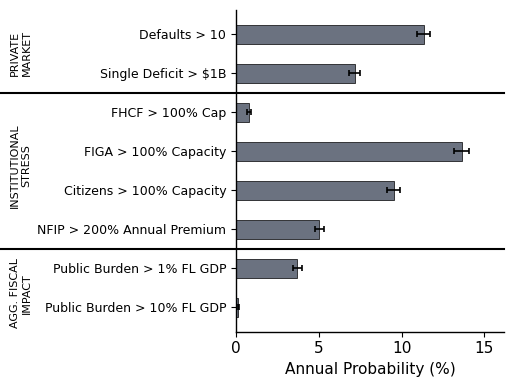

In [5]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5, 4))

# Reverse order for display (bottom to top)
df_reversed = df_era5_metrics[::-1].reset_index(drop=True)
values = df_reversed['Annual Probability (%)'].values

# Get uncertainty bounds
p10_vals = df_reversed['P10'].values
p90_vals = df_reversed['P90'].values

# Calculate error bars (asymmetric)
lower_errors = values - p10_vals
upper_errors = p90_vals - values

# Single color for all bars
colors = '#6B7280'

bars = ax.barh(df_reversed['Metric'], values, height=0.5, 
               xerr=[lower_errors, upper_errors],
               color=colors, edgecolor='black', linewidth=0.5,
               error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 2, 'capthick': 1.2})

# Add category separators
ax.axhline(y=1.5, color='black', linewidth=1.5, xmin=-1.5, xmax=1.0, clip_on=False)
ax.axhline(y=5.5, color='black', linewidth=1.5, xmin=-1.5, xmax=1.0, clip_on=False)

ax.set_xlabel('Annual Probability (%)', fontsize=11, fontweight='normal')
ax.set_xlim(0, max(p90_vals) * 1.15)

# Remove grid
ax.grid(False)

# Style axes
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', colors='black')
ax.tick_params(axis='y', labelsize=9)

# Add category labels
fig.text(0.00, 0.85, 'PRIVATE\nMARKET', fontsize=8, fontweight='normal', 
         va='center', ha='center', color='k', rotation=90)
fig.text(0.00, 0.57, 'INSTITUTIONAL\nSTRESS', fontsize=8, fontweight='normal', 
         va='center', ha='center', color='k', rotation=90)
fig.text(0.00, 0.25, 'AGG. FISCAL\nIMPACT', fontsize=8, fontweight='normal', 
         va='center', ha='center', color='k', rotation=90)

plt.tight_layout()
out_file = Path('../results/figures/fig_era5_systemic_risk_baseline.png')
out_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_file, dpi=300, bbox_inches='tight')
plt.show()

## Table 1: Return period estimates for loss decomposition and public institutional stress

In [6]:
# Function to compute return period values
def compute_return_periods(data, return_periods=[10, 25, 50, 100, 250, 500, 1000]):
    """
    Compute return period values from annual data.
    
    Parameters:
    -----------
    data : array-like
        Annual values (e.g., losses, deficits)
    return_periods : list
        Return periods to compute (in years)
    
    Returns:
    --------
    dict : Dictionary mapping return period to exceedance value
    """
    rp_values = {}
    for rp in return_periods:
        # Return period corresponds to 1/RP exceedance probability
        # e.g., RP100 = 1% annual exceedance = 99th percentile
        exceedance_prob = 1.0 / rp
        quantile = 1.0 - exceedance_prob
        rp_values[f'RP{rp}'] = np.quantile(data, quantile)
    return rp_values

In [7]:
# Define metrics to analyze
loss_metrics = {
    'Wind Insured (Private)': 'wind_insured_private_usd',
    'Wind Insured (Citizens)': 'wind_insured_citizens_usd',
    'Flood Insured (NFIP)': 'flood_insured_capped_usd',
    'Wind Un/Underinsured': None,  # Computed
    'Flood Un/Underinsured': None,  # Computed
}

institutional_metrics = {
    'FHCF Shortfall': 'fhcf_shortfall_usd',
    'FIGA Residual': 'figa_residual_deficit_usd',
    'Citizens Deficit': 'citizens_residual_deficit_usd',
    'NFIP Borrowed': 'nfip_borrowed_usd',
}

# Compute derived metrics
baseline_results['wind_underinsured'] = (baseline_results['wind_total_usd'] - 
                                   baseline_results['wind_insured_private_usd'] - 
                                   baseline_results['wind_insured_citizens_usd'])
baseline_results['flood_underinsured'] = (baseline_results['water_total_usd'] - 
                                    baseline_results['flood_insured_capped_usd'])

loss_metrics['Wind Un/Underinsured'] = 'wind_underinsured'
loss_metrics['Flood Un/Underinsured'] = 'flood_underinsured'

# Compute summary statistics for all metrics
return_periods = [10, 25, 50, 100, 250, 500, 1000]
summary_data = []

# Process loss metrics
for metric_name, column_name in loss_metrics.items():
    data = baseline_results[column_name].values
    
    # Annual expected value
    annual_exp = data.mean() / 1e9
    
    # Return periods
    rp_values = compute_return_periods(data, return_periods)
    
    row = {'Metric': metric_name, 'Category': 'Loss', 'Annual EV': annual_exp}
    for rp_name, value in rp_values.items():
        row[rp_name] = value / 1e9
    
    summary_data.append(row)

# Add total losses row
baseline_results['total_losses'] = (baseline_results['wind_insured_private_usd'] + 
                                    baseline_results['wind_insured_citizens_usd'] + 
                                    baseline_results['flood_insured_capped_usd'] + 
                                    baseline_results['wind_underinsured'] + 
                                    baseline_results['flood_underinsured'])

total_data = baseline_results['total_losses'].values
total_annual_exp = total_data.mean() / 1e9
total_rp_values = compute_return_periods(total_data, return_periods)

total_row = {'Metric': 'Total Losses', 'Category': 'Loss', 'Annual EV': total_annual_exp}
for rp_name, value in total_rp_values.items():
    total_row[rp_name] = value / 1e9

summary_data.append(total_row)

# Process institutional metrics
for metric_name, column_name in institutional_metrics.items():
    data = baseline_results[column_name].values
    
    # Annual expected value
    annual_exp = data.mean() / 1e9
    
    # Return periods
    rp_values = compute_return_periods(data, return_periods)
    
    row = {'Metric': metric_name, 'Category': 'Institutional', 'Annual EV': annual_exp}
    for rp_name, value in rp_values.items():
        row[rp_name] = value / 1e9
    
    summary_data.append(row)

# Create summary DataFrame
df_summary = pd.DataFrame(summary_data)

# Save to CSV
tables_dir = Path('../results/tables')
df_summary.to_csv(tables_dir / 'baseline_metrics_return_periods.csv', index=False)

---
## Fig. 4: Climate Change Impact on Systemic Risk

Comparison of systemic risk metrics across GCM-driven climate scenarios.

For this analysis, we'll work with return period summary data rather than individual iterations, as the climate delta analysis scales return period metrics.

In [8]:
# Check if climate delta files exist
climate_dir = Path('../results/climate_deltas')

if not climate_dir.exists():
    print("⚠️  Climate delta directory not found")
    print("    Run: python fl_risk_model/analysis/compute_climate_deltas.py \\")
    print("              --mc_root results/mc_runs --out results/climate_deltas")
    climate_data_available = False
else:
    # Check for required files
    required_files = [
        'era5_climate_scaled_absolute.csv',
        'era5_climate_scaled_relative.csv',
        'gcm_era5_alignment.csv',
        'climate_deltas_ensemble_absolute.csv'
    ]
    
    missing_files = [f for f in required_files if not (climate_dir / f).exists()]
    
    if missing_files:
        print(f"⚠️  Missing files: {missing_files}")
        print("    Run climate delta analysis script first")
        climate_data_available = False
    else:
        climate_data_available = True
        
        # Load the data
        df_era5_scaled_abs = pd.read_csv(climate_dir / 'era5_climate_scaled_absolute.csv')
        df_era5_scaled_rel = pd.read_csv(climate_dir / 'era5_climate_scaled_relative.csv')
        df_gcm_alignment = pd.read_csv(climate_dir / 'gcm_era5_alignment.csv')
        df_deltas_ensemble = pd.read_csv(climate_dir / 'climate_deltas_ensemble_absolute.csv')

In [9]:
if climate_data_available:
    # Use the ABSOLUTE delta approach (recommended to avoid GCM bias amplification)
    df_climate = df_era5_scaled_abs.copy()
    
    # Define key systemic risk metrics (matching Section 2)
    key_metrics = [
        'total_damage_usd',
        'defaults_post', 
        'largest_entity_deficit_usd',
        'fhcf_recovery_private_usd',
        'fhcf_recovery_citizens_usd',
        'figa_residual_deficit_usd',
        'citizens_residual_deficit_usd',
        'nfip_borrowed_usd',
        'fhcf_shortfall_usd'
    ]
    
    # Check which metrics are available
    available_metrics = [m for m in key_metrics if m in df_climate['metric'].values]
    
    
    if len(available_metrics) > 0:
        # Data is already at annual average level (no return periods)
        # Extract values for each time period
        
        results = []
        
        for time_cat in ['near', 'mid']:
            for metric in available_metrics:
                metric_data = df_climate[
                    (df_climate['metric'] == metric) &
                    (df_climate['time_category'] == time_cat)
                ]
                
                if len(metric_data) == 0:
                    continue
                
                row = metric_data.iloc[0]
                baseline = row['era5_baseline']
                scaled = row['scaled_median']
                scaled_p10 = row['scaled_p10']
                scaled_p90 = row['scaled_p90']
                
                pct_change = ((scaled - baseline) / baseline * 100) if baseline > 0 else 0
                
                results.append({
                    'time_category': time_cat,
                    'metric': metric,
                    'baseline': baseline,
                    'scaled_median': scaled,
                    'scaled_p10': scaled_p10,
                    'scaled_p90': scaled_p90,
                    'pct_change': pct_change
                })
        
        df_climate_summary = pd.DataFrame(results)

In [10]:
if climate_data_available and len(available_metrics) > 0:
    # Now we have real SSP5-8.5 data with pathway column!
    # Load data separated by pathway
    
    
    # Calculate baseline probabilities from baseline_results (from Section 2) with p10-p90 ranges
    baseline_probs = {}
    baseline_probs_p10 = {}
    baseline_probs_p90 = {}
    
    result = compute_uncertainty_bounds(baseline_results['defaults_post'] > 10)
    baseline_probs['Defaults > 10'] = result['mean']
    baseline_probs_p10['Defaults > 10'] = result['p10']
    baseline_probs_p90['Defaults > 10'] = result['p90']
    
    result = compute_uncertainty_bounds(baseline_results['largest_entity_deficit_usd'] > 1e9)
    baseline_probs['Single Deficit > $1B'] = result['mean']
    baseline_probs_p10['Single Deficit > $1B'] = result['p10']
    baseline_probs_p90['Single Deficit > $1B'] = result['p90']
    
    result = compute_uncertainty_bounds((baseline_results['fhcf_recovery_private_usd'] + 
                         baseline_results['fhcf_recovery_citizens_usd']) / FHCF_CAP > 1.0)
    baseline_probs['FHCF > 100% Cap'] = result['mean']
    baseline_probs_p10['FHCF > 100% Cap'] = result['p10']
    baseline_probs_p90['FHCF > 100% Cap'] = result['p90']
    
    result = compute_uncertainty_bounds(baseline_results['figa_residual_deficit_usd'] > 0)
    baseline_probs['FIGA > 100% Capacity'] = result['mean']
    baseline_probs_p10['FIGA > 100% Capacity'] = result['p10']
    baseline_probs_p90['FIGA > 100% Capacity'] = result['p90']
    
    result = compute_uncertainty_bounds(baseline_results['citizens_residual_deficit_usd'] / 
                                  (baseline_results['citizens_tier1_capacity_usd'] + 
                                   baseline_results['citizens_tier2_capacity_usd']) > 1.0)
    baseline_probs['Citizens > 100% Capacity'] = result['mean']
    baseline_probs_p10['Citizens > 100% Capacity'] = result['p10']
    baseline_probs_p90['Citizens > 100% Capacity'] = result['p90']
    
    result = compute_uncertainty_bounds(baseline_results['nfip_claims_paid_usd'] / 
                                    baseline_results['nfip_fl_premium_base_usd'] > 2.0)
    baseline_probs['NFIP > 200% Annual Premium'] = result['mean']
    baseline_probs_p10['NFIP > 200% Annual Premium'] = result['p10']
    baseline_probs_p90['NFIP > 200% Annual Premium'] = result['p90']
    
    # Aggregate fiscal impact metrics
    total_public_burden = (
        baseline_results['fhcf_shortfall_usd'] + 
        baseline_results['figa_residual_deficit_usd'] + 
        baseline_results['citizens_residual_deficit_usd'] + 
        baseline_results['nfip_borrowed_usd']
    )
    FL_GDP = 1.7e12  # $1.7 trillion (2024-25)
    
    result = compute_uncertainty_bounds(total_public_burden > 0.01 * FL_GDP)
    baseline_probs['Public Burden > 1% FL GDP'] = result['mean']
    baseline_probs_p10['Public Burden > 1% FL GDP'] = result['p10']
    baseline_probs_p90['Public Burden > 1% FL GDP'] = result['p90']
    
    result = compute_uncertainty_bounds(total_public_burden > 0.10 * FL_GDP)
    baseline_probs['Public Burden > 10% FL GDP'] = result['mean']
    baseline_probs_p10['Public Burden > 10% FL GDP'] = result['p10']
    baseline_probs_p90['Public Burden > 10% FL GDP'] = result['p90']
    
    def estimate_future_prob_with_uncertainty(metric, baseline_prob, pathway, time_cat):
        """
        Estimate future probability with uncertainty from GCM ensemble.
        
        Returns: (median_prob, p10_prob, p90_prob)
        """
        metric_data = df_era5_scaled_abs[
            (df_era5_scaled_abs['metric'] == metric) &
            (df_era5_scaled_abs['pathway'] == pathway) &
            (df_era5_scaled_abs['time_category'] == time_cat)
        ]
        
        if metric_data.empty:
            return (baseline_prob, baseline_prob, baseline_prob)
        
        row = metric_data.iloc[0]
        baseline_val = row['era5_baseline']
        
        if baseline_val == 0:
            return (baseline_prob, baseline_prob, baseline_prob)
        
        # Calculate scaling factors for median, p10, p90
        scaling_median = row['scaled_median'] / baseline_val
        scaling_p10 = row['scaled_p10'] / baseline_val
        scaling_p90 = row['scaled_p90'] / baseline_val
        
        # Scale probability (use sqrt to avoid unrealistic values)
        prob_median = min(baseline_prob * np.sqrt(scaling_median), 99.9)
        prob_p10 = min(baseline_prob * np.sqrt(scaling_p10), 99.9)
        prob_p90 = min(baseline_prob * np.sqrt(scaling_p90), 99.9)
        
        return (prob_median, prob_p10, prob_p90)
    
    # Create comparison data with uncertainty
    comparison_data = []
    
    # Select metrics to show
    display_metrics = [
        ('Defaults > 10', 'defaults_post'),
        ('Single Deficit > $1B', 'largest_entity_deficit_usd'),
        ('FHCF > 100% Cap', None),  # Composite metric
        ('FIGA > 100% Capacity', 'figa_residual_deficit_usd'),
        ('Citizens > 100% Capacity', 'citizens_residual_deficit_usd'),
        ('NFIP > 200% Annual Premium', None),
        ('Public Burden > 1% FL GDP', None),  # Composite metric
        ('Public Burden > 10% FL GDP', None)  # Composite metric
    ]
    
    for metric_name, data_metric in display_metrics:
        baseline_val = baseline_probs.get(metric_name, 0)
        baseline_p10 = baseline_probs_p10.get(metric_name, baseline_val)
        baseline_p90 = baseline_probs_p90.get(metric_name, baseline_val)
        
        # Initialize with baseline (with Monte Carlo uncertainty)
        row_data = {
            'Metric': metric_name,
            'Baseline': baseline_val,
            'Baseline_p10': baseline_p10,
            'Baseline_p90': baseline_p90,
        }
        
        if data_metric and data_metric in df_era5_scaled_abs['metric'].values:
            # Get values for each pathway/time combination
            near_245_med, near_245_p10, near_245_p90 = estimate_future_prob_with_uncertainty(
                data_metric, baseline_val, 'ssp245', 'near')
            near_585_med, near_585_p10, near_585_p90 = estimate_future_prob_with_uncertainty(
                data_metric, baseline_val, 'ssp585', 'near')
            mid_245_med, mid_245_p10, mid_245_p90 = estimate_future_prob_with_uncertainty(
                data_metric, baseline_val, 'ssp245', 'mid')
            mid_585_med, mid_585_p10, mid_585_p90 = estimate_future_prob_with_uncertainty(
                data_metric, baseline_val, 'ssp585', 'mid')
            
            row_data.update({
                '2050 SSP2-4.5': near_245_med,
                '2050 SSP2-4.5_p10': near_245_p10,
                '2050 SSP2-4.5_p90': near_245_p90,
                '2050 SSP5-8.5': near_585_med,
                '2050 SSP5-8.5_p10': near_585_p10,
                '2050 SSP5-8.5_p90': near_585_p90,
                '2100 SSP2-4.5': mid_245_med,
                '2100 SSP2-4.5_p10': mid_245_p10,
                '2100 SSP2-4.5_p90': mid_245_p90,
                '2100 SSP5-8.5': mid_585_med,
                '2100 SSP5-8.5_p10': mid_585_p10,
                '2100 SSP5-8.5_p90': mid_585_p90,
            })
        else:
            # For composite metrics, use average scaling from all metrics
            # Get average scaling factors per pathway/time
            scaling_factors = {}
            for pathway in ['ssp245', 'ssp585']:
                for time_cat in ['near', 'mid']:
                    subset = df_era5_scaled_abs[
                        (df_era5_scaled_abs['pathway'] == pathway) &
                        (df_era5_scaled_abs['time_category'] == time_cat)
                    ]
                    if not subset.empty:
                        avg_median = (subset['scaled_median'] / subset['era5_baseline']).mean()
                        avg_p10 = (subset['scaled_p10'] / subset['era5_baseline']).mean()
                        avg_p90 = (subset['scaled_p90'] / subset['era5_baseline']).mean()
                        
                        # Conservative scaling for composite metrics (0.5 factor)
                        prob_med = min(baseline_val * np.sqrt(avg_median) * 0.8, 99.9)
                        prob_p10 = min(baseline_val * np.sqrt(avg_p10) * 0.8, 99.9)
                        prob_p90 = min(baseline_val * np.sqrt(avg_p90) * 0.8, 99.9)
                        
                        key = f'{"2050" if time_cat == "near" else "2100"} {"SSP2-4.5" if pathway == "ssp245" else "SSP5-8.5"}'
                        row_data[key] = prob_med
                        row_data[f'{key}_p10'] = prob_p10
                        row_data[f'{key}_p90'] = prob_p90
        
        comparison_data.append(row_data)
    
    df_climate_comparison = pd.DataFrame(comparison_data)

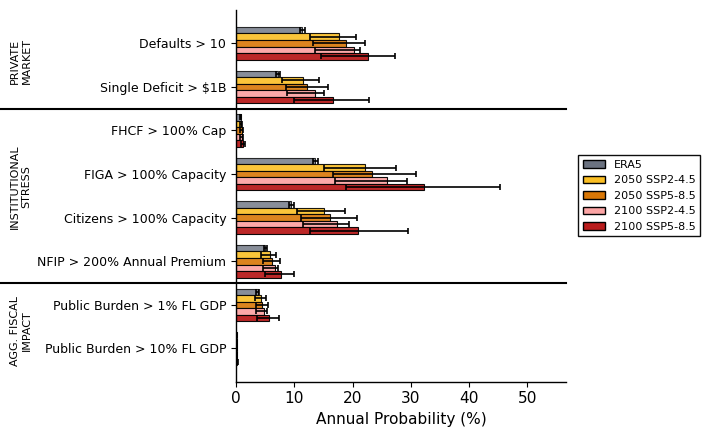

In [11]:
from matplotlib.patches import Patch

# ---- Desired top-to-bottom order ----
desired_order = [
    # PRIVATE MARKET
    'Defaults > 10',
    'Single Deficit > $1B',

    # INSTITUTIONAL CAPACITY
    'FHCF > 100% Cap',
    'FIGA > 100% Capacity',
    'Citizens > 100% Capacity',
    'NFIP > 200% Annual Premium',

    # AGGREGATE FISCAL IMPACT
    'Public Burden > 1% FL GDP',
    'Public Burden > 10% FL GDP'
]

df_climate_comparison = (
    df_climate_comparison
    .set_index('Metric')
    .reindex(desired_order)
    .reset_index()
)

# Create visualization with uncertainty bars
fig, ax = plt.subplots(figsize=(7, 4.5))

# Metric order now explicitly controlled above
y_pos = np.arange(len(df_climate_comparison))
n_scenarios = 5
width = 0.75 / n_scenarios

# Extract median values
baseline_vals    = df_climate_comparison['Baseline'].values
near_ssp245_vals = df_climate_comparison['2050 SSP2-4.5'].values
near_ssp585_vals = df_climate_comparison['2050 SSP5-8.5'].values
mid_ssp245_vals  = df_climate_comparison['2100 SSP2-4.5'].values
mid_ssp585_vals  = df_climate_comparison['2100 SSP5-8.5'].values

# Calculate error bars (asymmetric)
def get_error_bars(df, col_prefix):
    """Get asymmetric error bars (lower, upper)."""
    medians = df[col_prefix].values
    p10s = df.get(f'{col_prefix}_p10', medians)
    p90s = df.get(f'{col_prefix}_p90', medians)

    lower = np.maximum(medians - p10s, 0)  # Don't go below 0
    upper = np.maximum(p90s - medians, 0)
    return [lower, upper]

near_245_err = get_error_bars(df_climate_comparison, '2050 SSP2-4.5')
near_585_err = get_error_bars(df_climate_comparison, '2050 SSP5-8.5')
mid_245_err  = get_error_bars(df_climate_comparison, '2100 SSP2-4.5')
mid_585_err  = get_error_bars(df_climate_comparison, '2100 SSP5-8.5')
baseline_err = get_error_bars(df_climate_comparison, 'Baseline')

# ---- Colors: 3 categories with variants ----
color_baseline  = "#6B7280"  # neutral gray

# Mid-century (2050): same family, two shades
color_2050_245  = '#FBBF24'  # lighter amber
color_2050_585  = '#D97706'  # darker amber

# End-century (2100): same family, two shades
color_2100_245  = '#FCA5A5'  # lighter red
color_2100_585  = '#B91C1C'  # darker red

# ---- Bar positions: baseline at top, then 2050, then 2100 ----
# Top -> bottom within each metric row:
# Baseline (highest), 2050 SSP2-4.5, 2050 SSP5-8.5, 2100 SSP2-4.5, 2100 SSP5-8.5
offsets = np.array([-2*width, -1*width, 0, 1*width, 2*width])

# Create bars with error bars
ax.barh(
    y_pos + offsets[0], baseline_vals, width,
    xerr=baseline_err, color=color_baseline, edgecolor='black', linewidth=0.8,
    alpha=0.8,
    error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 2, 'capthick': 1.2}
)

ax.barh(
    y_pos + offsets[1], near_ssp245_vals, width,
    xerr=near_245_err, color=color_2050_245, edgecolor='black', linewidth=0.8,
    alpha=0.9,
    error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 2, 'capthick': 1.2}
)

ax.barh(
    y_pos + offsets[2], near_ssp585_vals, width,
    xerr=near_585_err, color=color_2050_585, edgecolor='black', linewidth=0.8,
    alpha=0.9,
    error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 2, 'capthick': 1.2}
)

ax.barh(
    y_pos + offsets[3], mid_ssp245_vals, width,
    xerr=mid_245_err, color=color_2100_245, edgecolor='black', linewidth=0.8,
    alpha=0.95,
    error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 2, 'capthick': 1.2}
)

ax.barh(
    y_pos + offsets[4], mid_ssp585_vals, width,
    xerr=mid_585_err, color=color_2100_585, edgecolor='black', linewidth=0.8,
    alpha=0.95,
    error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 2, 'capthick': 1.2}
)

# ---- Axis limits (robust to NaN/Inf) ----
all_vals = np.concatenate([
    baseline_vals, near_ssp245_vals, near_ssp585_vals,
    mid_ssp245_vals, mid_ssp585_vals
])

finite_all = all_vals[np.isfinite(all_vals)]
if finite_all.size == 0:
    max_val = 1.0  # fallback if everything is NaN
else:
    max_val = finite_all.max()

if '2100 SSP5-8.5_p90' in df_climate_comparison.columns:
    p90_vals = df_climate_comparison['2100 SSP5-8.5_p90'].values
    finite_p90 = p90_vals[np.isfinite(p90_vals)]
    if finite_p90.size > 0:
        max_val = max(max_val, finite_p90.max())

# Final sanity fallback (in case max_val is still non-finite)
if not np.isfinite(max_val) or max_val <= 0:
    max_val = 1.0

ax.set_xlim(0, max_val * 1.25)

# ---- Category separators (for 2 / 4 / 2 rows) ----
# After index 1 (2 private metrics) and after index 5 (4 institutional metrics)
if len(df_climate_comparison) >= 8:
    ax.axhline(y=1.5, color='black', linewidth=1.5, xmin=-1.5, xmax=1.0, clip_on=False)
    ax.axhline(y=5.5, color='black', linewidth=1.5, xmin=-1.5, xmax=1.0, clip_on=False)

# Formatting
ax.set_xlabel('Annual Probability (%)', fontsize=11, fontweight='normal')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_climate_comparison['Metric'], fontsize=9)
ax.invert_yaxis()  # <- this makes the desired_order appear top-to-bottom

ax.grid(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', colors='black')
ax.tick_params(axis='y', labelsize=9)

# ---- Legend as bbox center-right ----
legend_handles = [
    Patch(facecolor=color_baseline,  edgecolor='black', label='ERA5'),
    Patch(facecolor=color_2050_245, edgecolor='black', label='2050 SSP2-4.5'),
    Patch(facecolor=color_2050_585, edgecolor='black', label='2050 SSP5-8.5'),
    Patch(facecolor=color_2100_245, edgecolor='black', label='2100 SSP2-4.5'),
    Patch(facecolor=color_2100_585, edgecolor='black', label='2100 SSP5-8.5'),
]

ax.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fancybox=False,
    edgecolor='black',
    framealpha=0.95,
    fontsize=8,
)

# Category labels (positions tuned for 8 rows)
if len(df_climate_comparison) >= 8:
    fig.text(0.00, 0.85, 'PRIVATE\nMARKET', fontsize=8, fontweight='normal',
             va='center', ha='center', color='k', rotation=90)
    fig.text(0.00, 0.57, 'INSTITUTIONAL\nSTRESS', fontsize=8, fontweight='normal',
             va='center', ha='center', color='k', rotation=90)
    fig.text(0.00, 0.25, 'AGG. FISCAL\nIMPACT', fontsize=8, fontweight='normal',
             va='center', ha='center', color='k', rotation=90)

plt.tight_layout()

out_file = Path('../results/figures/fig_climate_systemic_risk_scenarios.png')
plt.savefig(out_file, dpi=300, bbox_inches='tight')
plt.show()

---
## Fig. 5: Policy Scenario Comparison

Compare systemic risk probabilities under different policy interventions:
- **Baseline**: No intervention
- **Market Exit (Moderate)**: 10% of high-risk properties exit private market
- **Penetration (Major)**: 40% increase in flood insurance take-up
- **Building Codes (Major)**: 20% damage reduction from stricter codes

In [12]:
# Load policy sensitivity runs
# Run output dirs: emanuel_era5_{policy}_TIMESTAMP
policy_configs = {
    'baseline': 'emanuel_era5_baseline',
    'market_exit': 'emanuel_era5_market_exit_moderate',
    'penetration': 'emanuel_era5_penetration_major',
    'building_codes': 'emanuel_era5_building_codes_major',
}

policy_results = {}
for policy_name, prefix in policy_configs.items():
    run_dir = get_latest_run(prefix)
    if run_dir:
        df = load_mc_results(run_dir)
        if df is not None:
            policy_results[policy_name] = df

In [13]:
# Only proceed if we have policy data
if len(policy_results) > 0:
    # Calculate metrics for each policy scenario directly from 10,000 MC years
    policy_metrics = {}
    policy_metrics_p10 = {}
    policy_metrics_p90 = {}

    # Map internal keys to display names
    display_names = {
        'baseline': 'Baseline',
        'market_exit': 'Market Exit',
        'penetration': 'Penetration',
        'building_codes': 'Building Codes',
    }

    for scenario_key, df_scenario in policy_results.items():
        scenario_name = display_names.get(scenario_key, scenario_key)
        # Filter out errors
        df_valid_policy = df_scenario[df_scenario['scenario'] != 'error'].copy()
        
        metrics = {}
        metrics_p10 = {}
        metrics_p90 = {}
        
        # Private market metrics
        defaults_10 = (df_valid_policy['defaults_post'] > 10)
        unc = compute_uncertainty_bounds(defaults_10)
        metrics['Defaults > 10'] = unc['mean']
        metrics_p10['Defaults > 10'] = unc['p10']
        metrics_p90['Defaults > 10'] = unc['p90']
        
        deficit_1b = (df_valid_policy['largest_entity_deficit_usd'] > 1e9)
        unc = compute_uncertainty_bounds(deficit_1b)
        metrics['Single Deficit > $1B'] = unc['mean']
        metrics_p10['Single Deficit > $1B'] = unc['p10']
        metrics_p90['Single Deficit > $1B'] = unc['p90']
        
        # Institutional stress metrics
        fhcf_cap_exceeded = (df_valid_policy['fhcf_recovery_private_usd'] + df_valid_policy['fhcf_recovery_citizens_usd']) / FHCF_CAP > 1.0
        unc = compute_uncertainty_bounds(fhcf_cap_exceeded)
        metrics['FHCF > 100% Cap'] = unc['mean']
        metrics_p10['FHCF > 100% Cap'] = unc['p10']
        metrics_p90['FHCF > 100% Cap'] = unc['p90']
        
        figa_capacity_exceeded = df_valid_policy['figa_residual_deficit_usd'] > 0
        unc = compute_uncertainty_bounds(figa_capacity_exceeded)
        metrics['FIGA > 100% Capacity'] = unc['mean']
        metrics_p10['FIGA > 100% Capacity'] = unc['p10']
        metrics_p90['FIGA > 100% Capacity'] = unc['p90']
        
        citizens_capacity_exceeded = df_valid_policy['citizens_residual_deficit_usd'] / (df_valid_policy['citizens_tier1_capacity_usd'] + df_valid_policy['citizens_tier2_capacity_usd']) > 1.0
        unc = compute_uncertainty_bounds(citizens_capacity_exceeded)
        metrics['Citizens > 100% Capacity'] = unc['mean']
        metrics_p10['Citizens > 100% Capacity'] = unc['p10']
        metrics_p90['Citizens > 100% Capacity'] = unc['p90']
        
        nfip_stressed = df_valid_policy['nfip_claims_paid_usd'] / df_valid_policy['nfip_fl_premium_base_usd'] > 2.0
        unc = compute_uncertainty_bounds(nfip_stressed)
        metrics['NFIP > 200% Annual Premium'] = unc['mean']
        metrics_p10['NFIP > 200% Annual Premium'] = unc['p10']
        metrics_p90['NFIP > 200% Annual Premium'] = unc['p90']
        
        # Aggregate fiscal impact metrics (relative to Florida GDP)
        total_public_burden_policy = (
            df_valid_policy['fhcf_shortfall_usd'] + 
            df_valid_policy['figa_residual_deficit_usd'] + 
            df_valid_policy['citizens_residual_deficit_usd'] + 
            df_valid_policy['nfip_borrowed_usd']
        )
        
        FL_GDP = 1.7e12  # $1.7 trillion (2024-25)
        
        pub_burden_1pct = (total_public_burden_policy > 0.01 * FL_GDP)
        unc = compute_uncertainty_bounds(pub_burden_1pct)
        metrics['Public Burden > 1% FL GDP'] = unc['mean']
        metrics_p10['Public Burden > 1% FL GDP'] = unc['p10']
        metrics_p90['Public Burden > 1% FL GDP'] = unc['p90']
        
        pub_burden_10pct = (total_public_burden_policy > 0.10 * FL_GDP)
        unc = compute_uncertainty_bounds(pub_burden_10pct)
        metrics['Public Burden > 10% FL GDP'] = unc['mean']
        metrics_p10['Public Burden > 10% FL GDP'] = unc['p10']
        metrics_p90['Public Burden > 10% FL GDP'] = unc['p90']
        
        policy_metrics[scenario_name] = metrics
        policy_metrics_p10[scenario_name] = metrics_p10
        policy_metrics_p90[scenario_name] = metrics_p90
    
    # Create comparison DataFrame
    # Order: Baseline, Market Exit, Penetration, Building Codes
    scenario_order = ['Baseline', 'Market Exit', 'Penetration', 'Building Codes']
    available_scenarios = [s for s in scenario_order if s in policy_metrics]
    
    # Build dataframe with mean and uncertainty bounds
    df_policy_comparison = pd.DataFrame({
        'Metric': metric_names
    })
    
    for scenario in available_scenarios:
        df_policy_comparison[scenario] = [policy_metrics[scenario][m] for m in metric_names]
        df_policy_comparison[f'{scenario}_P10'] = [policy_metrics_p10[scenario][m] for m in metric_names]
        df_policy_comparison[f'{scenario}_P90'] = [policy_metrics_p90[scenario][m] for m in metric_names]
    
    # Reverse for display
    df_policy_comparison_display = df_policy_comparison[::-1].reset_index(drop=True)
    
    
    # Display only mean values for table
    display_cols = ['Metric'] + available_scenarios
else:
    print("\n⚠️  Skipping policy comparison - no policy data available yet")

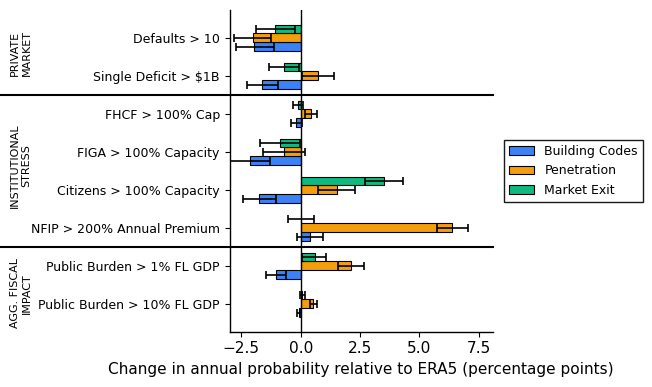

In [14]:
# Alternative visualization: Divergence from baseline with diverging bar plot
if len(policy_results) >= 2 and 'Baseline' in available_scenarios:
    # Calculate divergence from baseline for each scenario
    baseline_vals = df_policy_comparison_display['Baseline'].values
    baseline_p10 = df_policy_comparison_display['Baseline_P10'].values
    baseline_p90 = df_policy_comparison_display['Baseline_P90'].values
    
    # Get non-baseline scenarios (reversed so Market Exit is at top)
    policy_scenarios_only = [s for s in available_scenarios if s != 'Baseline']
    policy_scenarios_only = policy_scenarios_only[::-1]  # Reverse order
    
    if len(policy_scenarios_only) > 0:
        fig, ax = plt.subplots(figsize=(6.5,4))
        
        # Prepare data
        y_pos = np.arange(len(df_policy_comparison_display))
        n_scenarios = len(policy_scenarios_only)
        bar_height = 0.7 / n_scenarios  # Height of each bar
        
        # Define colors for each scenario (excluding baseline)
        colors_map = {
            'Market Exit': '#10B981',    # Green
            'Penetration': '#F59E0B',    # Amber
            'Building Codes': '#3B82F6'  # Blue
        }
        
        # Plot each policy scenario's divergence as horizontal bars
        for i, scenario in enumerate(policy_scenarios_only):
            # Get scenario values and uncertainty
            scenario_vals = df_policy_comparison_display[scenario].values
            scenario_p10 = df_policy_comparison_display[f'{scenario}_P10'].values
            scenario_p90 = df_policy_comparison_display[f'{scenario}_P90'].values
            
            # Calculate divergence (percentage points)
            divergence = scenario_vals - baseline_vals
            
            # Propagate uncertainty: for differences, uncertainties combine
            # Lower bound of difference: scenario_p10 - baseline_p90
            # Upper bound of difference: scenario_p90 - baseline_p10
            divergence_lower = scenario_p10 - baseline_p90
            divergence_upper = scenario_p90 - baseline_p10
            
            # Calculate error bar values
            lower_errors = divergence - divergence_lower
            upper_errors = divergence_upper - divergence
            
            # Position offset for each scenario
            y_offset = (i - (n_scenarios - 1) / 2) * bar_height
            
            # Plot diverging bars with error bars
            ax.barh(y_pos + y_offset, divergence, bar_height,
                   xerr=[lower_errors, upper_errors],
                   color=colors_map[scenario], edgecolor='black', linewidth=0.8,
                   label=scenario,
                   error_kw={'linewidth': 1.2, 'ecolor': 'black', 'capsize': 3, 'capthick': 1.2})
        
        # Add vertical line at zero (baseline reference)
        ax.axvline(x=0, color='k', linewidth=1.0, linestyle='-', zorder=1)
        
        # Add category separators (extended beyond plot area)
        ax.axhline(y=1.5, color='black', linewidth=1.5, linestyle='-', 
                   xmin=-1.5, xmax=1.0, clip_on=False)
        ax.axhline(y=5.5, color='black', linewidth=1.5, linestyle='-',
                   xmin=-1.5, xmax=1.0, clip_on=False)
        
        ax.set_xlabel('Change in annual probability relative to ERA5 (percentage points)', fontsize=11, fontweight='normal')
        ax.set_ylabel('')
        
        # Set y-axis
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_policy_comparison_display['Metric'], fontsize=9)
        
        # Set x-axis limits: cap left side at -3, calculate right side dynamically
        all_divergences = []
        for scenario in policy_scenarios_only:
            scenario_vals = df_policy_comparison_display[scenario].values
            scenario_p10 = df_policy_comparison_display[f'{scenario}_P10'].values
            scenario_p90 = df_policy_comparison_display[f'{scenario}_P90'].values
            all_divergences.extend((scenario_vals - baseline_vals).tolist())
            all_divergences.extend((scenario_p10 - baseline_p90).tolist())
            all_divergences.extend((scenario_p90 - baseline_p10).tolist())
        
        if all_divergences:
            max_positive = max(all_divergences)
            ax.set_xlim(-3, max_positive * 1.15)
        else:
            ax.set_xlim(-3, 3)
        
        # Remove all grids
        ax.grid(False)
        
        # Style axes
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', colors='black')
        ax.tick_params(axis='y', labelsize=9)
        
        # Add legend on the right side
        ax.legend(loc='center left', frameon=True, fancybox=False, 
                  edgecolor='black', framealpha=0.9, fontsize=9, 
                  ncol=1, bbox_to_anchor=(1.02, 0.5))
        
        # Add category labels
        fig.text(0.01, 0.85, 'PRIVATE\nMARKET', fontsize=8, fontweight='normal', 
                 va='center', ha='center', color='k', rotation=90)
        fig.text(0.01, 0.57, 'INSTITUTIONAL\nSTRESS', fontsize=8, fontweight='normal', 
                 va='center', ha='center', color='k', rotation=90)
        fig.text(0.01, 0.25, 'AGG. FISCAL\nIMPACT', fontsize=8, fontweight='normal', 
                 va='center', ha='center', color='k', rotation=90)
        
        plt.tight_layout()
        out_file = Path('../results/figures/fig_era5_policy_divergence.png')
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        plt.show()
        
    else:
        print("\n⚠️  No policy scenarios available besides baseline")
else:
    print("\n⚠️  Need baseline + policy scenarios to create divergence plot")

## Table S4: Loss decomposition and public institutional burden across climate and policy scenarios

In [15]:
# Prepare loss decomposition data for different scenarios
# We'll show: Baseline, 4 climate scenarios, and available policy scenarios

loss_data = {}
institutional_data = {}

# ===== BASELINE (ERA5) =====
# Calculate mean and percentiles for baseline
baseline_losses = {
    'insured_wind': baseline_results['wind_insured_private_usd'] / 1e9,
    'citizens': baseline_results['wind_insured_citizens_usd'] / 1e9,
    'insured_flood': baseline_results['flood_insured_capped_usd'] / 1e9,
    'wind_under': (baseline_results['wind_total_usd'] - 
                   baseline_results['wind_insured_private_usd'] - 
                   baseline_results['wind_insured_citizens_usd']) / 1e9,
    'flood_under': (baseline_results['water_total_usd'] - 
                    baseline_results['flood_insured_capped_usd']) / 1e9
}

loss_data['Baseline\n(ERA5)'] = {
    'insured_wind': baseline_losses['insured_wind'].mean(),
    'insured_wind_p10': baseline_losses['insured_wind'].quantile(0.10),
    'insured_wind_p90': baseline_losses['insured_wind'].quantile(0.90),
    'citizens': baseline_losses['citizens'].mean(),
    'citizens_p10': baseline_losses['citizens'].quantile(0.10),
    'citizens_p90': baseline_losses['citizens'].quantile(0.90),
    'insured_flood': baseline_losses['insured_flood'].mean(),
    'insured_flood_p10': baseline_losses['insured_flood'].quantile(0.10),
    'insured_flood_p90': baseline_losses['insured_flood'].quantile(0.90),
    'wind_under': baseline_losses['wind_under'].mean(),
    'wind_under_p10': baseline_losses['wind_under'].quantile(0.10),
    'wind_under_p90': baseline_losses['wind_under'].quantile(0.90),
    'flood_under': baseline_losses['flood_under'].mean(),
    'flood_under_p10': baseline_losses['flood_under'].quantile(0.10),
    'flood_under_p90': baseline_losses['flood_under'].quantile(0.90),
}

# Add total losses
total_loss = sum([baseline_losses[k].mean() for k in ['insured_wind', 'citizens', 'insured_flood', 'wind_under', 'flood_under']])
total_loss_p10 = sum([baseline_losses[k].quantile(0.10) for k in ['insured_wind', 'citizens', 'insured_flood', 'wind_under', 'flood_under']])
total_loss_p90 = sum([baseline_losses[k].quantile(0.90) for k in ['insured_wind', 'citizens', 'insured_flood', 'wind_under', 'flood_under']])

loss_data['Baseline\n(ERA5)']['total_loss'] = total_loss
loss_data['Baseline\n(ERA5)']['total_loss_p10'] = total_loss_p10
loss_data['Baseline\n(ERA5)']['total_loss_p90'] = total_loss_p90

# Calculate institutional data with uncertainties
baseline_inst = {
    'fhcf_shortfall': baseline_results['fhcf_shortfall_usd'] / 1e9,
    'figa_residual': baseline_results['figa_residual_deficit_usd'] / 1e9,
    'citizens_deficit': baseline_results['citizens_residual_deficit_usd'] / 1e9,
    'nfip_borrowed': baseline_results['nfip_borrowed_usd'] / 1e9
}

institutional_data['Baseline\n(ERA5)'] = {
    'fhcf_shortfall': baseline_inst['fhcf_shortfall'].mean(),
    'fhcf_shortfall_p10': baseline_inst['fhcf_shortfall'].quantile(0.10),
    'fhcf_shortfall_p90': baseline_inst['fhcf_shortfall'].quantile(0.90),
    'figa_residual': baseline_inst['figa_residual'].mean(),
    'figa_residual_p10': baseline_inst['figa_residual'].quantile(0.10),
    'figa_residual_p90': baseline_inst['figa_residual'].quantile(0.90),
    'citizens_deficit': baseline_inst['citizens_deficit'].mean(),
    'citizens_deficit_p10': baseline_inst['citizens_deficit'].quantile(0.10),
    'citizens_deficit_p90': baseline_inst['citizens_deficit'].quantile(0.90),
    'nfip_borrowed': baseline_inst['nfip_borrowed'].mean(),
    'nfip_borrowed_p10': baseline_inst['nfip_borrowed'].quantile(0.10),
    'nfip_borrowed_p90': baseline_inst['nfip_borrowed'].quantile(0.90),
}

# ===== CLIMATE SCENARIOS (if available) =====
# Check if climate data exists
if 'df_climate' in dir():
    climate_scenarios_list = [
        ('2050\nSSP2-4.5', 'ssp245', 'near'),
        ('2050\nSSP5-8.5', 'ssp585', 'near'),
        ('2100\nSSP2-4.5', 'ssp245', 'mid'),
        ('2100\nSSP5-8.5', 'ssp585', 'mid')
    ]
    
    for label, pathway, time_cat in climate_scenarios_list:
        # Get scaled values from df_climate for all relevant metrics
        climate_subset = df_climate[
            (df_climate['pathway'] == pathway) &
            (df_climate['time_category'] == time_cat)
        ]
        
        if not climate_subset.empty:
            # Helper function to get scaled values with uncertainties
            def get_scaled_values(metric_name):
                metric_row = climate_subset[climate_subset['metric'] == metric_name]
                if not metric_row.empty:
                    row = metric_row.iloc[0]
                    return {
                        'mean': row['scaled_median'] / 1e9,
                        'p10': row['scaled_p10'] / 1e9 if 'scaled_p10' in row else row['scaled_median'] / 1e9,
                        'p90': row['scaled_p90'] / 1e9 if 'scaled_p90' in row else row['scaled_median'] / 1e9,
                    }
                return {'mean': 0.0, 'p10': 0.0, 'p90': 0.0}
            
            # Extract loss components
            insured_wind = get_scaled_values('wind_insured_private_usd')
            citizens = get_scaled_values('wind_insured_citizens_usd')
            insured_flood = get_scaled_values('flood_insured_capped_usd')
            wind_under = get_scaled_values('wind_underinsured_usd')
            flood_under = get_scaled_values('flood_un_derinsured_usd')
            
            loss_data[label] = {
                'insured_wind': insured_wind['mean'],
                'insured_wind_p10': insured_wind['p10'],
                'insured_wind_p90': insured_wind['p90'],
                'citizens': citizens['mean'],
                'citizens_p10': citizens['p10'],
                'citizens_p90': citizens['p90'],
                'insured_flood': insured_flood['mean'],
                'insured_flood_p10': insured_flood['p10'],
                'insured_flood_p90': insured_flood['p90'],
                'wind_under': wind_under['mean'],
                'wind_under_p10': wind_under['p10'],
                'wind_under_p90': wind_under['p90'],
                'flood_under': flood_under['mean'],
                'flood_under_p10': flood_under['p10'],
                'flood_under_p90': flood_under['p90'],
                'total_loss': (insured_wind['mean'] + citizens['mean'] + insured_flood['mean'] + 
                              wind_under['mean'] + flood_under['mean']),
                'total_loss_p10': (insured_wind['p10'] + citizens['p10'] + insured_flood['p10'] + 
                                  wind_under['p10'] + flood_under['p10']),
                'total_loss_p90': (insured_wind['p90'] + citizens['p90'] + insured_flood['p90'] + 
                                  wind_under['p90'] + flood_under['p90']),
            }
            
            # Extract institutional stress components
            fhcf = get_scaled_values('fhcf_shortfall_usd')
            figa = get_scaled_values('figa_residual_deficit_usd')
            cit_def = get_scaled_values('citizens_residual_deficit_usd')
            nfip = get_scaled_values('nfip_borrowed_usd')
            
            institutional_data[label] = {
                'fhcf_shortfall': fhcf['mean'],
                'fhcf_shortfall_p10': fhcf['p10'],
                'fhcf_shortfall_p90': fhcf['p90'],
                'figa_residual': figa['mean'],
                'figa_residual_p10': figa['p10'],
                'figa_residual_p90': figa['p90'],
                'citizens_deficit': cit_def['mean'],
                'citizens_deficit_p10': cit_def['p10'],
                'citizens_deficit_p90': cit_def['p90'],
                'nfip_borrowed': nfip['mean'],
                'nfip_borrowed_p10': nfip['p10'],
                'nfip_borrowed_p90': nfip['p90'],
            }
else:
    print("⚠️  Climate data (df_climate) not found. Run Section 5 first to load climate scenarios.")

# ===== POLICY SCENARIOS (if available) =====
if 'policy_results' in dir() and len(policy_results) > 0:
    for scenario_name, df_scenario in policy_results.items():
        if scenario_name == 'baseline':
            continue  # Skip baseline as we already have it
        
        df_valid_policy = df_scenario[df_scenario['scenario'] != 'error'].copy()
        
        # Calculate losses with uncertainties
        policy_losses = {
            'insured_wind': df_valid_policy['wind_insured_private_usd'] / 1e9,
            'citizens': df_valid_policy['wind_insured_citizens_usd'] / 1e9,
            'insured_flood': df_valid_policy['flood_insured_capped_usd'] / 1e9,
            'wind_under': (df_valid_policy['wind_total_usd'] - 
                           df_valid_policy['wind_insured_private_usd'] - 
                           df_valid_policy['wind_insured_citizens_usd']) / 1e9,
            'flood_under': (df_valid_policy['water_total_usd'] - 
                            df_valid_policy['flood_insured_capped_usd']) / 1e9
        }
        
        loss_data[scenario_name] = {
            'insured_wind': policy_losses['insured_wind'].mean(),
            'insured_wind_p10': policy_losses['insured_wind'].quantile(0.10),
            'insured_wind_p90': policy_losses['insured_wind'].quantile(0.90),
            'citizens': policy_losses['citizens'].mean(),
            'citizens_p10': policy_losses['citizens'].quantile(0.10),
            'citizens_p90': policy_losses['citizens'].quantile(0.90),
            'insured_flood': policy_losses['insured_flood'].mean(),
            'insured_flood_p10': policy_losses['insured_flood'].quantile(0.10),
            'insured_flood_p90': policy_losses['insured_flood'].quantile(0.90),
            'wind_under': policy_losses['wind_under'].mean(),
            'wind_under_p10': policy_losses['wind_under'].quantile(0.10),
            'wind_under_p90': policy_losses['wind_under'].quantile(0.90),
            'flood_under': policy_losses['flood_under'].mean(),
            'flood_under_p10': policy_losses['flood_under'].quantile(0.10),
            'flood_under_p90': policy_losses['flood_under'].quantile(0.90),
        }
        
        # Add total losses
        total_loss_pol = sum([policy_losses[k].mean() for k in ['insured_wind', 'citizens', 'insured_flood', 'wind_under', 'flood_under']])
        total_loss_pol_p10 = sum([policy_losses[k].quantile(0.10) for k in ['insured_wind', 'citizens', 'insured_flood', 'wind_under', 'flood_under']])
        total_loss_pol_p90 = sum([policy_losses[k].quantile(0.90) for k in ['insured_wind', 'citizens', 'insured_flood', 'wind_under', 'flood_under']])
        
        loss_data[scenario_name]['total_loss'] = total_loss_pol
        loss_data[scenario_name]['total_loss_p10'] = total_loss_pol_p10
        loss_data[scenario_name]['total_loss_p90'] = total_loss_pol_p90
        
        # Calculate institutional data with uncertainties
        policy_inst = {
            'fhcf_shortfall': df_valid_policy['fhcf_shortfall_usd'] / 1e9,
            'figa_residual': df_valid_policy['figa_residual_deficit_usd'] / 1e9,
            'citizens_deficit': df_valid_policy['citizens_residual_deficit_usd'] / 1e9,
            'nfip_borrowed': df_valid_policy['nfip_borrowed_usd'] / 1e9
        }
        
        institutional_data[scenario_name] = {
            'fhcf_shortfall': policy_inst['fhcf_shortfall'].mean(),
            'fhcf_shortfall_p10': policy_inst['fhcf_shortfall'].quantile(0.10),
            'fhcf_shortfall_p90': policy_inst['fhcf_shortfall'].quantile(0.90),
            'figa_residual': policy_inst['figa_residual'].mean(),
            'figa_residual_p10': policy_inst['figa_residual'].quantile(0.10),
            'figa_residual_p90': policy_inst['figa_residual'].quantile(0.90),
            'citizens_deficit': policy_inst['citizens_deficit'].mean(),
            'citizens_deficit_p10': policy_inst['citizens_deficit'].quantile(0.10),
            'citizens_deficit_p90': policy_inst['citizens_deficit'].quantile(0.90),
            'nfip_borrowed': policy_inst['nfip_borrowed'].mean(),
            'nfip_borrowed_p10': policy_inst['nfip_borrowed'].quantile(0.10),
            'nfip_borrowed_p90': policy_inst['nfip_borrowed'].quantile(0.90),
        }
else:
    print("⚠️  Policy scenarios not found. Only baseline data available.")

# ===== CONVERT TO DATAFRAMES AND SAVE TO CSV =====

# Convert loss_data to DataFrame
loss_df = pd.DataFrame.from_dict(loss_data, orient='index')
loss_df.index.name = 'Scenario'
loss_df = loss_df.reset_index()

# Convert institutional_data to DataFrame
institutional_df = pd.DataFrame.from_dict(institutional_data, orient='index')
institutional_df.index.name = 'Scenario'
institutional_df = institutional_df.reset_index()

# Save to CSV
tables_dir = Path('../results/tables')
tables_dir.mkdir(parents=True, exist_ok=True)

loss_df.to_csv(tables_dir / 'probabilistic_loss_data.csv', index=False)
institutional_df.to_csv(tables_dir / 'probabilistic_institutional_data.csv', index=False)

## Table S5: Probabilistic exceedance of systemic risk thresholds across climate and policy scenarios

In [16]:
# Create results/tables directory
tables_dir = Path('../results/tables')
tables_dir.mkdir(parents=True, exist_ok=True)

# Export ERA5 baseline metrics
df_era5_metrics.to_csv(tables_dir / 'era5_baseline_probabilities.csv', index=False)

# Export policy comparison if available
if len(policy_results) >= 2:
    df_policy_comparison.to_csv(tables_dir / 'era5_policy_comparison.csv', index=False)

# Export climate comparison if available
if 'df_climate_comparison' in dir() and df_climate_comparison is not None and not df_climate_comparison.empty:
    df_climate_comparison.to_csv(tables_dir / 'era5_climate_comparison.csv', index=False)

---
## Fig. 6: Building Code Sensitivity

Impact of building code improvements on wind and flood losses.

In [17]:
# Define building code levels (wind%, flood%)
building_code_levels = {
    'w00f00': (0, 0),
    'w20f13': (20, 13),
    'w30f20': (30, 20),
    'w40f27': (40, 27),
    'w50f33': (50, 33),
    'w60f40': (60, 40),
    'w70f47': (70, 47),
    'w80f53': (80, 53),
    'w90f60': (90, 60),
    'w100f67': (100, 67),
    'w110f70': (100, 70),
    'w120f80': (100, 80),
    'w130f90': (100, 90),
}

# GCM models to analyze
gcms = ['canesm', 'cnrm6', 'ecearth6', 'ipsl6', 'miroc6']

# Load GCM historical baselines using helper functions
gcm_baselines = {}
for gcm in gcms:
    run_dir = get_latest_run(f'emanuel_{gcm}_20thcal_baseline')
    if run_dir:
        df = load_mc_results(run_dir)
        if df is not None:
            gcm_baselines[gcm] = df

# Load GCM future runs with building codes
gcm_futures_with_codes = {}
for gcm in gcms:
    gcm_futures_with_codes[gcm] = {}
    for bc_label in building_code_levels:
        run_dir = get_latest_run(f'emanuel_{gcm}_ssp245cal_buildingcode_{bc_label}')
        if run_dir:
            df = load_mc_results(run_dir)
            if df is not None:
                gcm_futures_with_codes[gcm][bc_label] = df

# ERA5 baseline (reuse from cell 3 if available, otherwise load)
era5_baseline = baseline_results if baseline_results is not None else None

In [18]:
def compute_metrics(df):
    """Compute metrics that properly reflect building code reductions."""
    df_valid = df[df['scenario'] != 'error'].copy()
    if len(df_valid) == 0:
        return None
    
    metrics = {}
    
    # Economic burden components (all decrease with building codes)
    metrics['wind_insured_private_usd'] = df_valid['wind_insured_private_usd'].mean()
    metrics['wind_insured_citizens_usd'] = df_valid['wind_insured_citizens_usd'].mean()
    metrics['flood_insured_capped_usd'] = df_valid['flood_insured_capped_usd'].mean()
    metrics['wind_underinsured_usd'] = df_valid['wind_underinsured_usd'].mean()
    metrics['wind_uninsured_usd'] = df_valid['wind_uninsured_usd'].mean()
    
    # Private market stress
    metrics['defaults_post'] = df_valid['defaults_post'].mean()
    
    # Public sector deficits
    metrics['figa_residual_deficit_usd'] = df_valid['figa_residual_deficit_usd'].mean()
    metrics['citizens_residual_deficit_usd'] = df_valid['citizens_residual_deficit_usd'].mean()
    metrics['nfip_borrowed_usd'] = df_valid['nfip_borrowed_usd'].mean()
    metrics['fhcf_shortfall_usd'] = df_valid['fhcf_shortfall_usd'].mean()
    
    # Composite: Total insured loss
    metrics['total_insured_usd'] = (
        metrics['wind_insured_private_usd'] +
        metrics['wind_insured_citizens_usd'] +
        metrics['flood_insured_capped_usd']
    )
    
    # Composite: Total protected loss (insured + underinsured)
    metrics['total_protected_usd'] = (
        metrics['total_insured_usd'] +
        metrics['wind_underinsured_usd']
    )
    
    # Composite: Total economic burden (all losses)
    metrics['total_economic_burden_usd'] = (
        metrics['total_protected_usd'] +
        metrics['wind_uninsured_usd']
    )
    
    # Composite: Total public burden (all government deficits)
    metrics['total_public_burden_usd'] = (
        metrics['figa_residual_deficit_usd'] +
        metrics['citizens_residual_deficit_usd'] +
        metrics['nfip_borrowed_usd'] +
        metrics['fhcf_shortfall_usd']
    )
    
    return metrics

# Test on ERA5
if era5_baseline is not None:
    era5_metrics = compute_metrics(era5_baseline)

In [19]:
# Process each building code level
results = []

for bc_label, (wind_pct, flood_pct) in building_code_levels.items():
    # Collect deltas from all GCMs for this building code level
    gcm_deltas_bc = []
    
    for gcm in gcms:
        if bc_label not in gcm_futures_with_codes[gcm] or gcm not in gcm_baselines:
            continue
        
        metrics_bc = compute_metrics(gcm_futures_with_codes[gcm][bc_label])
        metrics_hist = compute_metrics(gcm_baselines[gcm])
        
        if metrics_bc and metrics_hist:
            delta = {k: metrics_bc[k] - metrics_hist[k] for k in metrics_bc.keys()}
            gcm_deltas_bc.append(delta)
    
    # Compute median AND p10/p90 climate delta across GCMs for this building code level
    if gcm_deltas_bc:
        climate_bc_delta_median = {}
        climate_bc_delta_p10 = {}
        climate_bc_delta_p90 = {}
        
        for metric in gcm_deltas_bc[0].keys():
            values = [d[metric] for d in gcm_deltas_bc]
            climate_bc_delta_median[metric] = np.median(values)
            climate_bc_delta_p10[metric] = np.percentile(values, 10)
            climate_bc_delta_p90[metric] = np.percentile(values, 90)
        
        # Apply climate delta to ERA5 baseline (median, p10, p90)
        era5_future_bc_median = {k: era5_metrics[k] + climate_bc_delta_median[k] for k in era5_metrics.keys()}
        era5_future_bc_p10 = {k: era5_metrics[k] + climate_bc_delta_p10[k] for k in era5_metrics.keys()}
        era5_future_bc_p90 = {k: era5_metrics[k] + climate_bc_delta_p90[k] for k in era5_metrics.keys()}
        
        # Store results
        combined_pct = (wind_pct + flood_pct) / 2
        results.append({
            'building_code_label': bc_label,
            'wind_pct': wind_pct,
            'flood_pct': flood_pct,
            'combined_pct': combined_pct,
            # Median values
            'economic_burden_b': era5_future_bc_median['total_economic_burden_usd'] / 1e9,
            'defaults': era5_future_bc_median['defaults_post'],
            'public_burden_b': era5_future_bc_median['total_public_burden_usd'] / 1e9,
            # P10 (lower bound)
            'economic_burden_b_p10': era5_future_bc_p10['total_economic_burden_usd'] / 1e9,
            'defaults_p10': era5_future_bc_p10['defaults_post'],
            'public_burden_b_p10': era5_future_bc_p10['total_public_burden_usd'] / 1e9,
            # P90 (upper bound)
            'economic_burden_b_p90': era5_future_bc_p90['total_economic_burden_usd'] / 1e9,
            'defaults_p90': era5_future_bc_p90['defaults_post'],
            'public_burden_b_p90': era5_future_bc_p90['total_public_burden_usd'] / 1e9,
        })
        
df_results = pd.DataFrame(results).sort_values('combined_pct')

In [20]:
# ERA5 baseline values for comparison
era5_baseline_values = {
    'economic_burden_b': era5_metrics['total_economic_burden_usd'] / 1e9,
    'defaults': era5_metrics['defaults_post'],
    'public_burden_b': era5_metrics['total_public_burden_usd'] / 1e9,
}

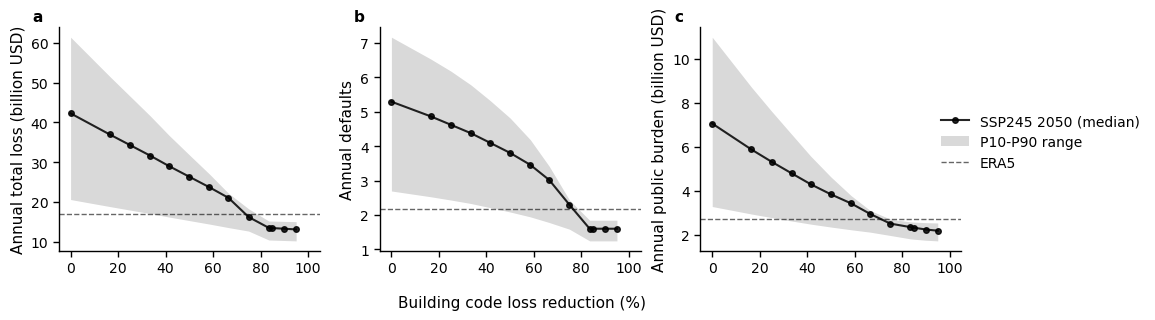

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(11,3), sharex=True, facecolor='white')

# Panel A: Total economic burden
ax = axes[0]
ax.set_facecolor('white')
# Median line
ax.plot(df_results['combined_pct'], df_results['economic_burden_b'], 
        'o-', color='k', alpha=0.85, linewidth=1.5, markersize=4, label='SSP245 2050 (median)', zorder=3)
# P10-P90 uncertainty band
ax.fill_between(df_results['combined_pct'], 
                df_results['economic_burden_b_p10'], 
                df_results['economic_burden_b_p90'],
                color='k', alpha=0.15, linewidth=0, label='P10-P90 range', zorder=1)
# Baseline
ax.axhline(era5_baseline_values['economic_burden_b'], color='k', 
           linestyle='--', linewidth=1.0, alpha=0.6, label='ERA5', zorder=2)
ax.set_ylabel('Annual total loss (billion USD)', fontsize=11)
ax.text(-0.1, 1.08, 'a', transform=ax.transAxes, fontsize=11, fontweight='bold', va='top')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(direction='out', length=4, width=1.0, labelsize=10)
ax.grid(False)
ax.set_xlim(-5, 105)

# Panel B: Defaults
ax = axes[1]
ax.set_facecolor('white')
# Median line
ax.plot(df_results['combined_pct'], df_results['defaults'], 
        'o-', color='k', alpha=0.85, linewidth=1.5, markersize=4, zorder=3)
# P10-P90 uncertainty band
ax.fill_between(df_results['combined_pct'], 
                df_results['defaults_p10'], 
                df_results['defaults_p90'],
                color='k', alpha=0.15, linewidth=0, zorder=1)
# Baseline
ax.axhline(era5_baseline_values['defaults'], color='k', 
           linestyle='--', linewidth=1.0, alpha=0.6, zorder=2)
ax.set_ylabel('Annual defaults', fontsize=11)
ax.text(-0.1, 1.08, 'b', transform=ax.transAxes, fontsize=11, fontweight='bold', va='top')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(direction='out', length=4, width=1.0, labelsize=10)
ax.grid(False)
ax.set_xlim(-5, 105)

# Panel C: Total public burden
ax = axes[2]
ax.set_facecolor('white')
# Median line
ax.plot(df_results['combined_pct'], df_results['public_burden_b'], 
        'o-', color='k', alpha=0.85, linewidth=1.5, markersize=4, zorder=3)
# P10-P90 uncertainty band
ax.fill_between(df_results['combined_pct'], 
                df_results['public_burden_b_p10'], 
                df_results['public_burden_b_p90'],
                color='k', alpha=0.15, linewidth=0, zorder=1)
# Baseline
ax.axhline(era5_baseline_values['public_burden_b'], color='k', 
           linestyle='--', linewidth=1.0, alpha=0.6, zorder=2)
ax.set_ylabel('Annual public burden (billion USD)', fontsize=11)
ax.text(-0.1, 1.08, 'c', transform=ax.transAxes, fontsize=11, fontweight='bold', va='top')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(direction='out', length=4, width=1.0, labelsize=10)
ax.grid(False)
ax.set_xlim(-5, 105)

# Shared x-axis label
fig.text(0.48, -0.05, 'Building code loss reduction (%)', ha='center', fontsize=11)

# Shared legend to the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.85, 0.5), 
           frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.88)

# Save figure
out_file = Path('../results/figures/fig_climate_buildingcode_sensitivity.png')
out_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## SI Fig. 1: Loss Return Period Curves

Exceedance probability curves for total damage.

In [22]:
# Load all events from Emanuel catalog (includes zero-damage events)
all_events_path = '../fl_risk_model/data/all_events.csv'
df_all_events = pd.read_csv(all_events_path)

In [23]:
# Use all_events.csv data for event-based return period curve
# This includes ALL events from the Emanuel catalog (8,800 total)

# Total events in catalog
N_TOTAL_CATALOG = len(df_all_events)

# Get event damages and IDs
event_damages = df_all_events['total_damage_usd'].values
event_ids = df_all_events['event_id'].values

In [24]:
# For event-based return periods, we need to account for:
# 1. The annual frequency (λ) from the Emanuel simulations
# 2. The TOTAL number of events in the catalog (all_events.csv)
# 3. Each event's individual frequency = λ / N_total

# ERA5 Emanuel parameters (from .mat file and hazard catalog)
LAMBDA_ERA5 = 1.8  # Mean annual frequency (events/year)
N_YEARS_ERA5 = 44  # Years in ERA5 dataset

# Verify catalog size matches expected

# Each event in the catalog has an individual frequency
freq_per_event = LAMBDA_ERA5 / N_TOTAL_CATALOG

# Compute event exceedance curve using CLIMADA methodology
# Reference: climada.engine.impact.Impact.calc_freq_curve()

# Assign equal frequency to all events
event_frequencies = np.full(len(event_damages), freq_per_event)

# CLIMADA approach:
# 1. Sort descendingly by impact
sort_idxs = np.argsort(event_damages)[::-1]

# 2. Calculate cumulative exceedance frequency (events/year exceeding each threshold)
exceed_freq = np.cumsum(event_frequencies[sort_idxs])

# 3. Compute return periods and reverse arrays to ascending order
event_return_period = (1 / exceed_freq)[::-1]
event_damages_sorted = event_damages[sort_idxs][::-1]

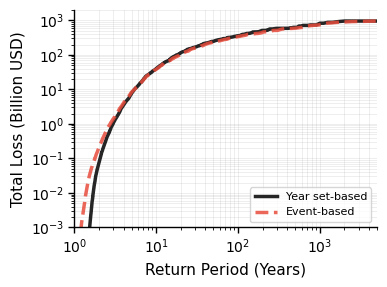

In [25]:
# Create event-based return period curve
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Compute event-set based (seasonal) return period curve from MC simulation
# Use the 10,000 year seasonal damages from baseline_results
seasonal_damages = baseline_results['total_damage_usd'].values
seasonal_damages_sorted = np.sort(seasonal_damages)[::-1]  # Sort descending
n_years = len(seasonal_damages_sorted)
seasonal_return_periods = n_years / np.arange(1, n_years + 1)  # RP = N / rank

# Plot event-set based (seasonal) curve
ax.plot(seasonal_return_periods, seasonal_damages_sorted / 1e9,
        linewidth=2.5, label='Year set-based', color='k', 
        alpha=0.85)

# Plot event-based curve (RP on x-axis, Damage on y-axis)
ax.plot(event_return_period, event_damages_sorted / 1e9,
        linewidth=2.5, label='Event-based', color='#E74C3C', 
        alpha=0.85, linestyle='--')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim(bottom=1e-3, top=2e3)  # Set y-axis minimum to 1 million USD (1e-3 billion)
ax.set_xlim(left=1, right=5000)  
ax.set_xlabel('Return Period (Years)', fontsize=11, fontweight='normal')
ax.set_ylabel('Total Loss (Billion USD)', fontsize=11, fontweight='normal')

# Set explicit tick locations and enable tick marks
ax.set_xticks([1, 10, 100, 1000])
ax.set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100, 1000])

# Show only bottom and left spines
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# Enable tick marks (seaborn whitegrid hides them by default)
ax.tick_params(axis='both', which='major', bottom=True, left=True, top=False, right=False,
               direction='out', length=4, width=1.0, color='k', labelsize=10)

ax.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)

# Add legend
ax.legend(fontsize=8, frameon=True, loc='lower right')

plt.tight_layout()

# Save figure
out_file = Path('../results/figures/fig_loss_return_period.png')
plt.savefig(out_file, dpi=300, bbox_inches='tight')
plt.show()